# **Catalogue Simulations for the WISEMAN simulator**

- **WISEMAN** \[1\] is a physics-based Monte Carlo C++ simulator built to assess the performace of the **Wide Field Monitor** (WFM) instrument, originally designed and developed for the LOFT, STROBE-X, eXTP and LEM-X \[2, 3\] space missions.

- This software provides a realistic photon-by-photon Monte Carlo simulation from the astrophysical sources down to the scientific data at the instrument level for a single WFM coded-mask camera. Each photon is generated at a given instant from a given sky direction and with a given energy, transported through a coded-mask camera, detected, and processed by the on-board front-end and back-end electronics.

- This notebook exploits the `wmsims` mini-package to simulate a given number of sources in a sky-field, with the possibility to specify custom PDFs for the sources coordinates and flux values distributions. The initialised sources are then stored into a database and saved as a `CSV` file.

**Libraries**

In [37]:
from typing import Callable

import numpy as np
from numpy.typing import NDArray
from pandas import DataFrame

from bloodmoon.mask import CodedMaskCamera
import darksun as ds
from darksun.data import Log

import wmsims as wm
from wmsims.fields import CameraPointer, Coords, Source

In [38]:
# plotting setup
ds.show.set_figures_darkbkg()

**Coded-mask cameras mask design and pointings setup**

In [39]:
base_path: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations"
#base_path: str = "/mnt/d/PhD_AASS/Coding/Images_fits"
MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"

wfm: CodedMaskCamera = wm.init_cameras_mask(f"{base_path}/{MASK_FITS}")
sdl: CameraPointer = wm.define_unit_pointings(
    z_axis_RA=266.4,
    z_axis_DEC=-28.94,
    x_axis_RA=266.4,
    x_axis_DEC=61.06,
)

**Catalogue setup**

In [40]:
n_sources: int = 10
fov: tuple[float, float] = (0.0, 40.0)   # [deg]
f_min: float = 4.0e-2                      # [Crab]
f_max: float = 10.0                        # [Crab]

**Simulate sources**

In [41]:
# -- simul sources camera local-frame angular sources
coords: tuple[Coords, ...] = wm.simul_coords(
    n_sources=n_sources,
    fov_along_x=fov,
    fov_along_y=fov,
)

# -- simul sources fluxes
## custom PDF kernel for sources flux distribution
#from scipy.special import gamma
#
#def mod_kernel(
#    x: NDArray,
#    alpha: float,
#    k: float,
#    beta: float,
#) -> NDArray:
#    """Custom exp - power law probability distribution function."""
#    f = (alpha + 1) / beta
#    a = beta * np.pow(k, f) / gamma(f)
#    t = - k * np.pow(x, beta)
#    return np.abs(a * np.pow(x, alpha) * np.exp(t))
#
#factors = (2.0, 4.0, 2.0)
#flux_pdf: Callable[[NDArray], NDArray] = wm.config_pdf(mod_kernel, *factors)
#
#fluxes: tuple[float, ...] = wm.simul_fluxes(
#    n_sources=n_sources,
#    f_min=f_min,
#    f_max=f_max,
#    pdf=flux_pdf,
#)

# handmade sources flux distribution
fluxes: tuple[float, ...] = wm.handmade_fluxes(
    n_sources=(2, 3, 5, 10, 7, 5, 2, 1, 1),
    flux_lims=(
        (4.0e-2, 7.0e-2), (7.0e-2, 1.0e-1), (1.0e-1, 4.0e-1),
        (4.0e-1, 8.0e-1), (8.0e-1, 9.0e-1), (9.0e-1, 1.0),
        (1.0, 2.0), (2.0, 3.0), (10.0, 15.0),
    ),
)

In [42]:
# coords: tuple[Coords, ...] = (
#     (-35.0, -35.0), (35.0, -35.0), (35.0, 35.0),
#     (-35.0, 35.0), (-15.0, -15.0), (15.0, -15.0),
#     (15.0, 15.0), (-15.0, 15.0), (0.0, 0.0),
# )
coords: tuple[Coords, ...] = (
    (-30.0, -30.0), (0.0, -30.0), (30.0, -30.0),
    (-30.0, 0.0), (0.0, 0.0), (30.0, 0.0),
    (-30.0, 30.0), (0.0, 30.0), (30.0, 30.0),
)
fluxes = np.ones(len(coords), dtype=float)

In [43]:
# -- get sources
sources: tuple[Source, ...] = wm.get_sources(coords, fluxes)

print(
    f"Total # of sources: {len(fluxes)}\n"
    f"Total flux from sources: {sum(fluxes):.3f} Crab\n"
)

Total # of sources: 9
Total flux from sources: 9.000 Crab



**Catalogue generation and visualisation**

In [44]:
SAVE_SKYFIELD: bool = True
SAVE_CATALOGUE: bool = True
SAVE_FLXDSTR: bool = False

SAVE_TO: str = '/home/edoardo/Desktop'
#SAVE_TO: str = '/mnt/d/PhD_AASS/Coding/Images_fits'

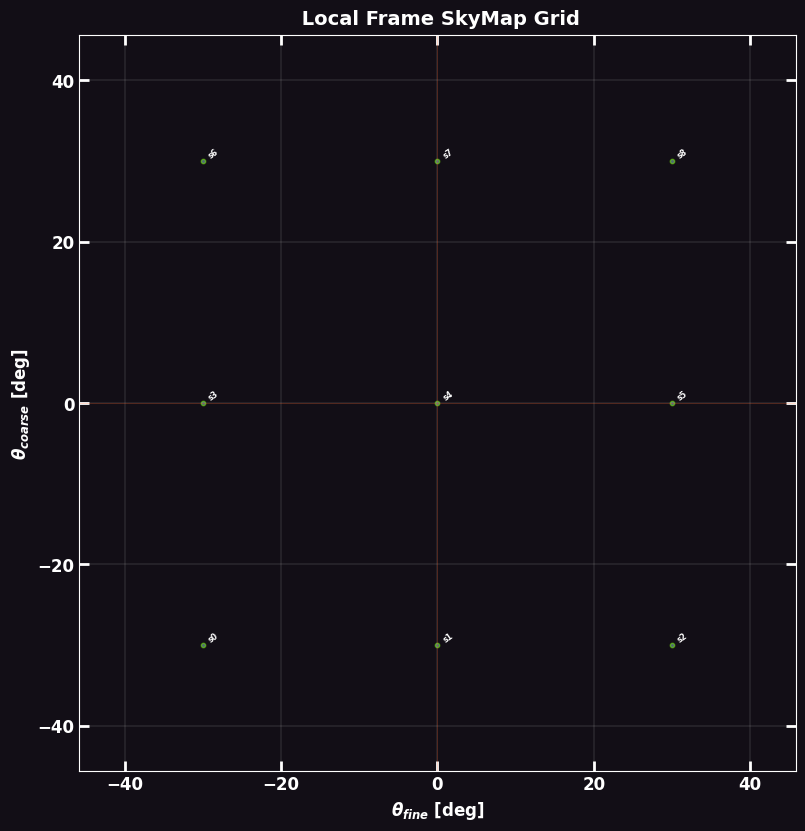

In [45]:
# gen Log structure for sources and show sky-field
log: Log = wm.gen_data_log(sources)

ds.skyfield_map(
    log=log,
    camera=wfm,
    show_IDs=True,
    save_to=(
        ds.savefile_to(SAVE_TO, 'skymap', overwrite=True)
        if SAVE_SKYFIELD else None
    ),
)

In [46]:
# - sources estimated significance
def analyse_skyfield(
    camera: CodedMaskCamera,
    sources: Source | tuple[Source, ...],
    snrmap: NDArray,
    threshold: int | float = 5.0,
) -> None:
    """Prints out sources with significance below threshold."""
    sources_: tuple[Source, ...] = (sources,) if isinstance(sources, Source) else sources
    for source in sources_:
        snrvalue: float = wm.get_source_snr(camera, source, snrmap)
        if snrvalue < threshold:
            print(
                f'# Source {source.ID} has significance {snrvalue:.3f}\n'
                f'  - flux: {source.flux:.3f} Crab\n'
                f'  - pos: ({source.angle_x:.3f}, {source.angle_y:.3f}) deg\n'
            )
    return None



exposure: int | float = 1e3   # [s]
sigmas: int | float = 5.0     # [adim]

snrmap: NDArray = wm.sky_significance(
    camera=wfm,
    sources=sources,
    exposure=exposure,
)
analyse_skyfield(wfm, sources, snrmap, sigmas)

## USING BULK MASK with 1.5 mm cover ##


In [47]:
# - gen catalogue dataframe
df: DataFrame = wm.make_catalog(
    sources=sources,
    snrmap=snrmap,
    sdl=sdl,
    camera=wfm,
    save_to=(
        f'{SAVE_TO}/geco_sensitivity_Crab-semigrid.csv' if SAVE_CATALOGUE else None
    ),
)

df

,ID,ANGLE_X,ANGLE_Y,RA,DEC,FLUX,SNR
0,s0,-30.0,-30.0,310.501363,-50.013058,1.0,67.970033
1,s1,0.0,-30.0,299.814161,-24.775510,1.0,124.007192
2,s2,30.0,-30.0,292.968974,0.948082,1.0,62.369137
3,s3,-30.0,0.0,266.400000,-58.940000,1.0,85.192030
4,s4,0.0,0.0,266.400000,-28.940000,1.0,163.571499
5,s5,30.0,0.0,266.400000,1.060000,1.0,85.192030
6,s6,-30.0,30.0,222.298637,-50.013058,1.0,62.369137
7,s7,0.0,30.0,232.985839,-24.775510,1.0,124.007192
8,s8,30.0,30.0,239.831026,0.948082,1.0,67.970033


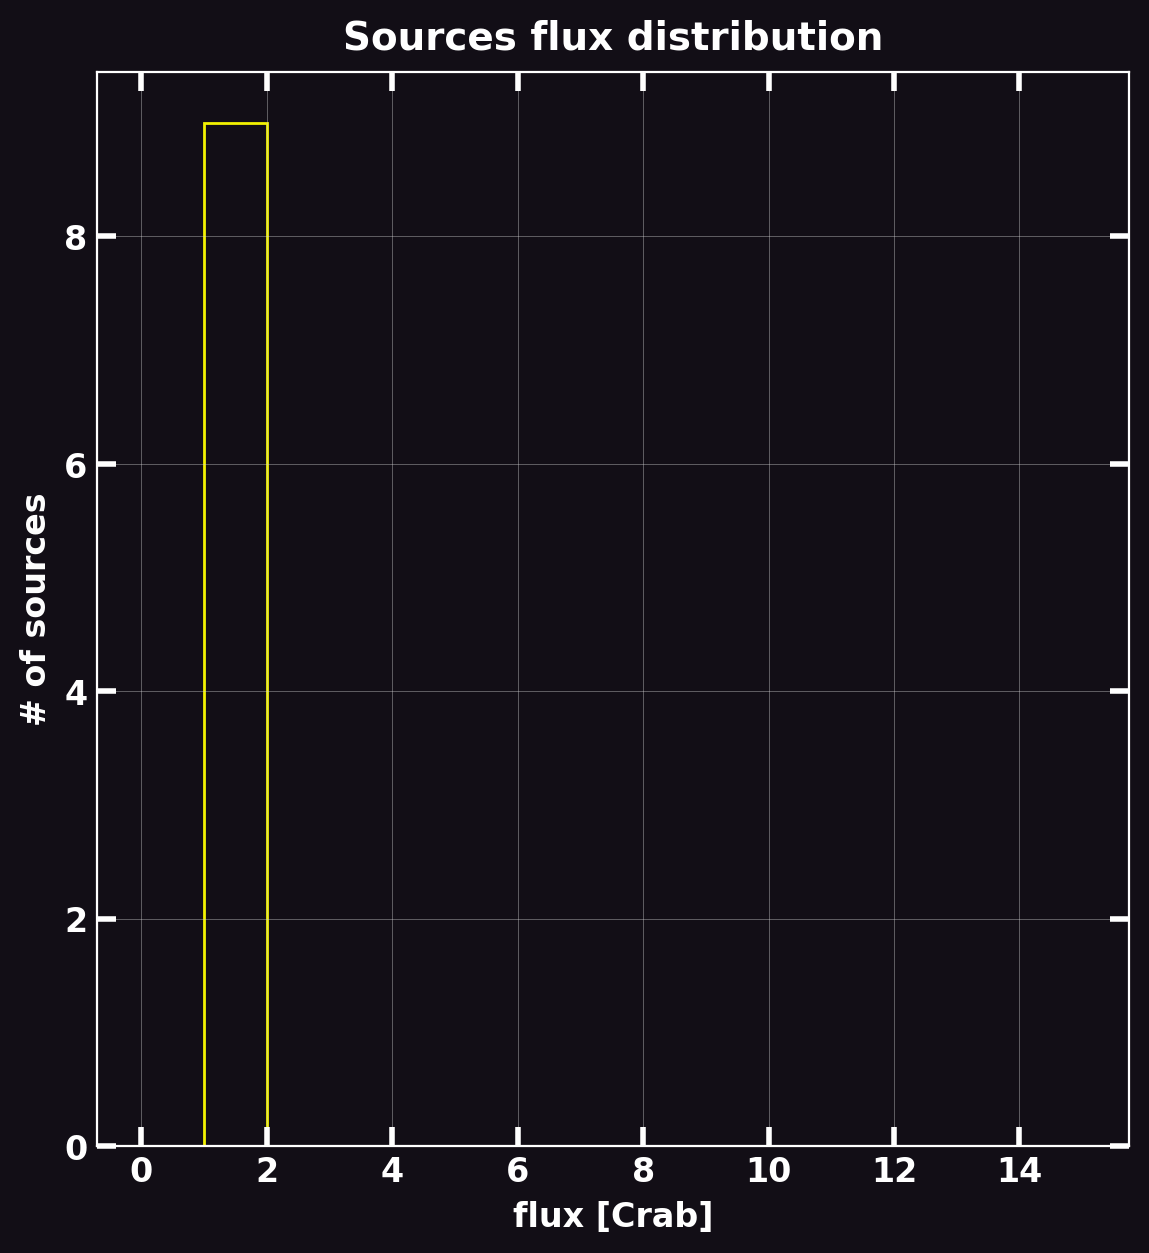

In [48]:
flux_bins = (
    4.0e-2, 7.0e-2, 1.0e-1, 4.0e-1, 8.0e-1, 9.0e-1, 1.0, 2.0, 3.0, 10.0, 15.0,
)

hist, bins = np.histogram(np.array(fluxes), bins=np.array(flux_bins), density=False)

dmap = ds.map4plot(
    arrs=hist,
    title='Sources flux distribution',
    xlabel='flux [Crab]',
    ylabel='# of sources',
    x=bins,
    style='stairs',
    color='Yellow',
)
ds.plot(
    dmap,
    save_to=(
        ds.savefile_to(SAVE_TO, 'flux_distr', overwrite=True)
        if SAVE_FLXDSTR else None
    ),
)

<br>
<br>

### **References**

**\[1\]** Ceraudo, F. et al. Development of the end-to-end simulator of the WFM camera, Vol. 13093 of Society of Photo-Optical Instrumentation Engineers (SPIE) Conference Series, 130936T (2024)

**\[2\]** Del Monte, E. et al., Status of the Lunar Electromagnetic Monitor in X-rays (LEM-X), in [Space Telescopes and Instrumentation 2024: Ultraviolet to Gamma Ray], den Herder, J.-W. A., Nikzad, S., and Nakazawa, K., eds., Society of Photo-Optical Instrumentation Engineers (SPIE) Conference Series 13093, this proceedings (2024)

**\[3\]** Del Monte, E. et al., The Lunar Electromagnetic Monitor in X-rays (LEM-X), _in preparation_, (2025)